# Laboratorio 4 - Clasificación multiclase multimodal


In [5]:
# Importación de las librerías necesarias
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Permite incrustar gráficos en el cuaderno
%matplotlib inline


### Dataset cargar los datos

Se inicia el ejercicio cargando primero el conjunto de datos.

In [ ]:

# 1. Cargar SOLO el dataset principal
print("Cargando el dataset...")

#Se utilizo el dataset de Kaggle "Challenges in Representation Learning: Facial Expression Recognition Challenge" que se encuentra en el archivo 'train.csv'
#https://www.kaggle.com/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/data
df_raw = pd.read_csv('train.csv')

# 2. Limpieza básica por si hay filas vacías
df_raw = df_raw.dropna(subset=['emotion', 'pixels'])

# 3. Balanceo del Dataset
min_ejemplos = df_raw['emotion'].value_counts().min()
print(f"Balanceando las 7 emociones a {int(min_ejemplos)} ejemplos cada una...")

df_balanceado = df_raw.groupby('emotion').sample(n=int(min_ejemplos), random_state=42).reset_index(drop=True)

# 4. Mezclar aleatoriamente
df_mezclado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. División 80% Entrenamiento / 20% Prueba (Partición manual)
limite = int(0.8 * len(df_mezclado))

df_train = df_mezclado.iloc[:limite]
df_test = df_mezclado.iloc[limite:]

# 6. Función SEGURA para extraer píxeles y filtrar cualquier imagen rota
def procesar_datos(df):
    pixeles_brutos = [np.array(x.split(), dtype=float) for x in df['pixels']]
    emociones_brutas = df['emotion'].values
    
    X_limpio = []
    y_limpio = []
    
    for i in range(len(pixeles_brutos)):
        if len(pixeles_brutos[i]) == 2304: # Solo aceptamos caras perfectas de 48x48
            X_limpio.append(pixeles_brutos[i])
            y_limpio.append(emociones_brutas[i])
            
    return np.array(X_limpio) / 255.0, np.array(y_limpio).astype(int)

print("Procesando píxeles (Esto tomará unos segundos)...")

# 7. Aplicar la función a las dos particiones
X_train, y_train = procesar_datos(df_train)
X_test, y_test = procesar_datos(df_test)

print(f"\nDatos de Entrenamiento (80%): X={X_train.shape}, y={y_train.shape}")
print(f"Datos de Prueba (20%): X={X_test.shape}, y={y_test.shape}")

Cargando el dataset...
Balanceando las 7 emociones a 436 ejemplos cada una...
Procesando píxeles (Esto tomará unos segundos)...

Datos de Entrenamiento (80%): X=(2441, 2304), y=(2441,)
Datos de Prueba (20%): X=(611, 2304), y=(611,)


In [16]:
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Oct 16 13:09:09 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 'y': array([[0],
        [0],
        [0],
        ...,
        [9],
        [9],
        [9]], dtype=uint8)}

### Visualización de los datos

Se comenzará visualizando un subconjunto del conjunto de entrenamiento.

In [9]:
def displayDataFER(X, y, example_width=48, figsize=(8, 8)):
    """
    Muestra datos 2D almacenados en X en una cuadrícula.
    Adaptado específicamente para rostros de 48x48.
    """
    m, n = X.shape
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    ax_array = [ax_array] if m == 1 else ax_array.ravel()
    
    emociones_txt = ['Enojo', 'Asco', 'Miedo', 'Feliz', 'Triste', 'Sorpresa', 'Neutral']

    for i, ax in enumerate(ax_array):
        # Hacemos el reshape a 48x48 sin el order='F'
        ax.imshow(X[i].reshape(example_width, example_width), cmap='gray')
        # Le ponemos de título la emoción que le corresponde
        ax.set_title(emociones_txt[y[i]], fontsize=10)
        ax.axis('off')
        
    plt.show()

Visualizando rostros aleatorios del conjunto de entrenamiento:


Visualizando rostros aleatorios del conjunto de entrenamiento:


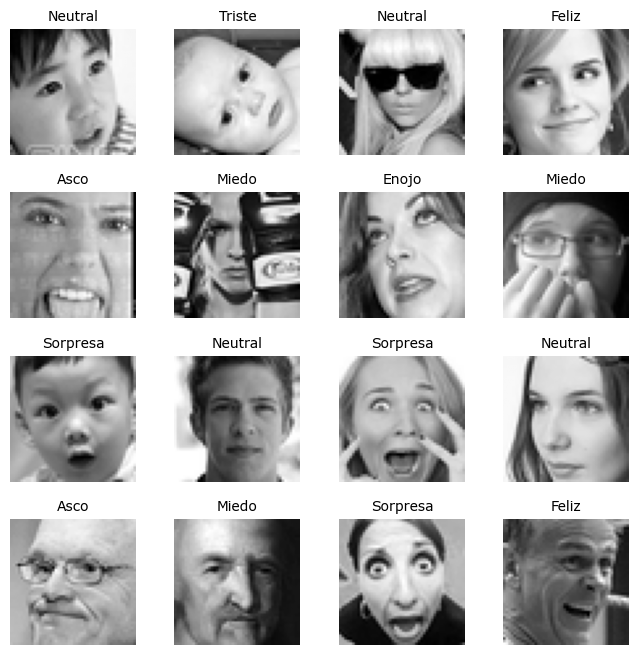

In [10]:
# Selecciona aleatoriamente 16 imágenes del conjunto de entrenamiento
rand_indices = np.random.choice(X_train.shape[0], 16, replace=False)
sel_X = X_train[rand_indices, :]
sel_y = y_train[rand_indices]

print("Visualizando rostros aleatorios del conjunto de entrenamiento:")
displayDataFER(sel_X, sel_y)

### Vectorización de regresión logística

Se utilizará múltiples modelos de regresión logística uno contra todos para construir un clasificador de clases múltiples.

In [15]:
# valores de prueba para los parámetros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)

# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

<a id="section1"></a>
#### Vectorización de la funcion de costo
<a id="lrCostFunction"></a>

In [16]:
def sigmoid(z):
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

In [18]:
def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))
    
    temp = theta.copy()
    temp[0] = 0 # No regularizamos el sesgo (bias)

    epsilon = 1e-5 # Prevenir log(0)
    
    J = (1 / m) * np.sum(-y.dot(np.log(h + epsilon)) - (1 - y).dot(np.log(1 - h + epsilon))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
    
    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

def descensoGradiente(theta, X, y, alpha, num_iters, lambda_):
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        cost, grad = lrCostFunction(theta, X, y, lambda_)
        theta = theta - alpha * grad
        J_history.append(cost)
        
    return theta, J_history

#### Vectorización regularizada de la regresión logística

Una vez implementada la vectorización para la regresión logística, corresponde agregarar regularización a la función de costo.


In [19]:
J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('Costo esperadot: 2.534819')
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))
print('Gradientes esperados:')
print(' [0.146561, -0.548558, 0.724722, 1.398003]');

Costo         : 2.534795
Costo esperadot: 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]
Gradientes esperados:
 [0.146561, -0.548558, 0.724722, 1.398003]


<a id="section2"></a>
### Clasificacion One-vs-all
En esta parte del ejercicio, se implementará la clasificación de uno contra todos mediante el entrenamiento de múltiples clasificadores de regresión logística regularizados
<a id="oneVsAll"></a>

Entrenando 7 clasificadores (Esto tomará unos minutos debido al tamaño del dataset)...


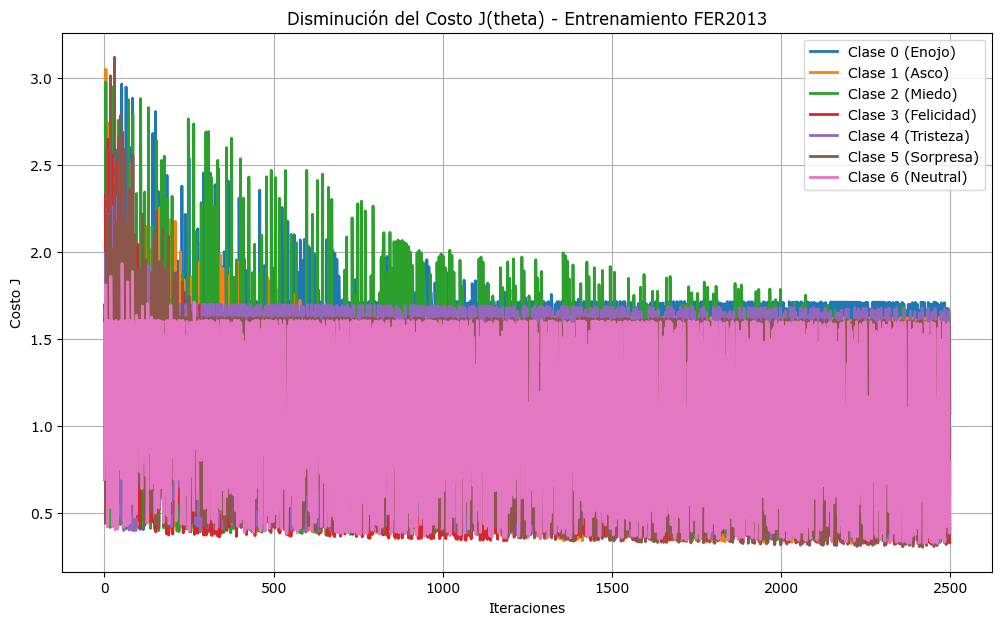

In [20]:
def oneVsAll(X, y, num_labels, lambda_, alpha, num_iters):
    m, n = X.shape 
    all_theta = np.zeros((num_labels, n + 1))
    
    # Agregamos la columna de unos para la intercepción (bias)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    plt.figure(figsize=(12, 7))
    emociones = ['Enojo', 'Asco', 'Miedo', 'Felicidad', 'Tristeza', 'Sorpresa', 'Neutral']
    
    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        # Vector binario: 1 si es la emoción actual, 0 en otro caso
        y_actual = np.where(y == c, 1, 0)
        
        # Ejecutamos descenso de gradiente
        theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters, lambda_)
        all_theta[c] = theta
        
        # Graficamos
        plt.plot(np.arange(len(J_history)), J_history, lw=2, label=f'Clase {c} ({emociones[c]})')

    plt.title('Disminución del Costo J(theta) - Entrenamiento FER2013')
    plt.xlabel('Iteraciones')
    plt.ylabel('Costo J')
    plt.legend()
    plt.grid(True)
    plt.show()

    return all_theta

# 3. Hiperparámetros MEJORADOS
num_labels = 7
lambda_ = 0.01     # (Antes 0.1) Reducimos la penalización para darle más libertad al modelo.
alpha = 0.1        # (Antes 0.5) Reducimos el tamaño del paso para que encuentre el fondo del pozo sin saltarlo.
num_iters = 2500   # (Antes 800) Le damos el triple de tiempo para que termine de aprender.

print("Entrenando 7 clasificadores (Esto tomará unos minutos debido al tamaño del dataset)...")
all_theta = oneVsAll(X_train, y_train, num_labels, lambda_, alpha, num_iters)

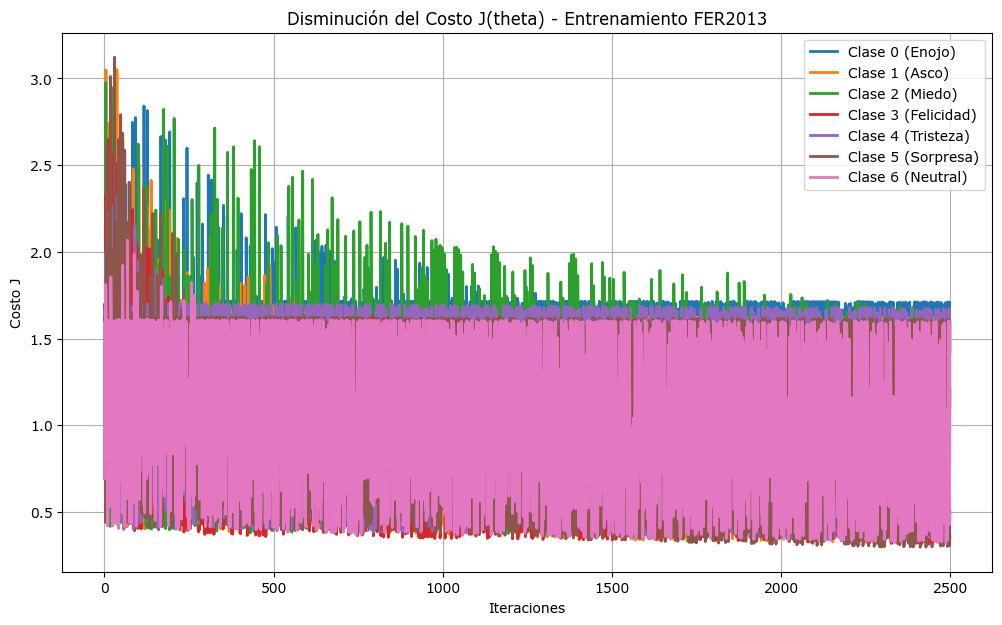

In [22]:
lambda_ = 0.001
num_iters = 2500 
all_theta = oneVsAll(X_train, y_train, num_labels, lambda_, alpha, num_iters)

In [24]:
print(all_theta.shape)
print(all_theta[0])

(7, 2305)
[ 0.8326837  -0.04984914  0.05407571 ...  0.01219631  0.06360828
 -0.13896297]


<a id="section3"></a>
#### Prediccion One-vs-all

Después de entrenar el clasificador de one-vs-all, se puede usarlo para predecir el dígito contenido en una imagen determinada.

Precisión final en el conjunto de prueba (Test 20%): 26.02%



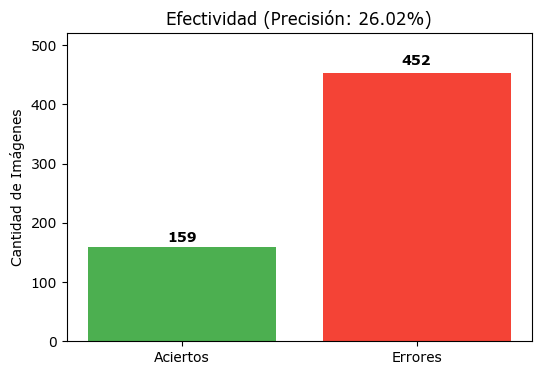

In [13]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)
    return p

# 1. Precisión Matemática
predicciones = predictOneVsAll(all_theta, X_test)
precision = np.mean(predicciones == y_test) * 100
print(f'Precisión final en el conjunto de prueba (Test 20%): {precision:.2f}%\n')

# 2. Gráfica de Efectividad
aciertos = np.sum(predicciones == y_test)
errores = len(y_test) - aciertos

plt.figure(figsize=(6, 4))
barras = plt.bar(['Aciertos', 'Errores'], [aciertos, errores], color=['#4CAF50', '#F44336'])
plt.title(f'Efectividad (Precisión: {precision:.2f}%)')
plt.ylabel('Cantidad de Imágenes')
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + (yval*0.02), int(yval), ha='center', va='bottom', fontweight='bold')
plt.ylim(0, max(aciertos, errores) * 1.15)
plt.show()

Una vez que haya terminado, se llama a la función `predictOneVsAll` usando el valor aprendido de $\theta$. Debería apreciarse que la precisión del conjunto de entrenamiento es de aproximadamente 95,1% (es decir, clasifica correctamente el 95,1% de los ejemplos del conjunto de entrenamiento).


--- PRUEBA VISUAL DE PREDICCIONES ---
Predicción del Modelo:  ['Miedo', 'Miedo', 'Miedo', 'Sorpresa', 'Sorpresa', 'Miedo', 'Miedo', 'Miedo', 'Sorpresa', 'Sorpresa', 'Sorpresa', 'Enojo', 'Miedo', 'Miedo', 'Miedo', 'Miedo']
Emoción Real:           ['Asco', 'Miedo', 'Triste', 'Miedo', 'Sorpresa', 'Neutral', 'Miedo', 'Triste', 'Neutral', 'Sorpresa', 'Sorpresa', 'Asco', 'Sorpresa', 'Neutral', 'Miedo', 'Enojo']


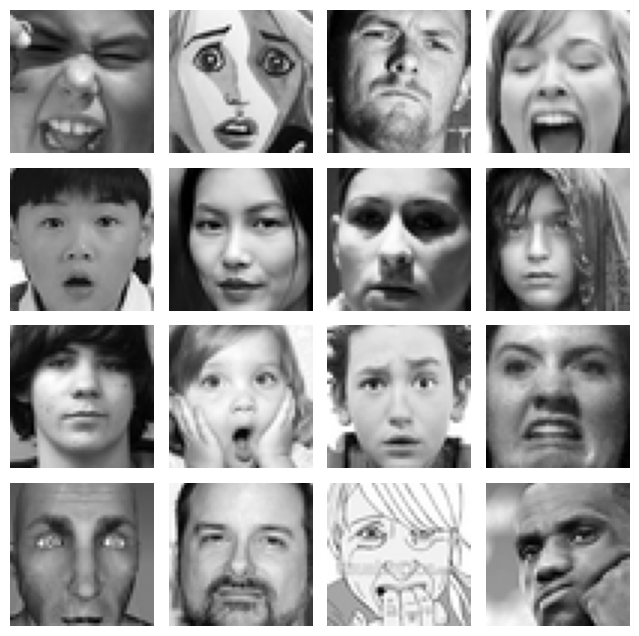

In [15]:
# 3. Visualización de los rostros y sus predicciones
def displayData(X, example_width=48, figsize=(8, 8)):
    m, n = X.shape
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.1, hspace=0.1)
    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        # FER2013 son imágenes cuadradas de 48x48
        ax.imshow(X[i].reshape(example_width, example_width), cmap='gray')
        ax.axis('off')
    plt.show()

# Seleccionamos 16 imágenes aleatorias del set de PRUEBA
rand_indices = np.random.choice(X_test.shape[0], 16, replace=False)
sel_X = X_test[rand_indices, :]
sel_y_real = y_test[rand_indices]
sel_y_pred = predictOneVsAll(all_theta, sel_X)

emociones_txt = ['Enojo', 'Asco', 'Miedo', 'Feliz', 'Triste', 'Sorpresa', 'Neutral']

print("\n--- PRUEBA VISUAL DE PREDICCIONES ---")
print("Predicción del Modelo: ", [emociones_txt[p] for p in sel_y_pred])
print("Emoción Real:          ", [emociones_txt[r] for r in sel_y_real])

displayData(sel_X)